# Worksheet 4 - Linear regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

**Open data:**

In [2]:
Sample_A = pd.read_csv('exoplanet_data.csv')

## 1 - Data exploration

**Drop NaN:**

In [3]:
Sample_A = Sample_A.dropna()
print('There are ', len(Sample_A), 'galaxies in this sample')
print(Sample_A)

There are  2695 galaxies in this sample
         pl_rade  pl_radeerr1  pl_radeerr2  pl_radelim     pl_masse  \
40     16.140960     0.336270    -0.336270         0.0  4417.837000   
117     1.947000     0.038000    -0.038000         0.0     8.590000   
122     1.875000     0.029000    -0.029000         0.0     7.990000   
123     2.173000     0.097000    -0.098000         0.0     8.370000   
129     2.080000     0.160000    -0.170000         0.0     7.810000   
...          ...          ...          ...         ...          ...   
39662  15.356304     0.336269    -0.336269         0.0   225.658169   
39677  11.130518     0.212971    -0.212971         0.0  6356.568140   
39755   2.060000     0.030000    -0.030000         0.0     4.520000   
39759   2.110000     0.050000    -0.050000         0.0     4.300000   
39762   2.042000     0.050000    -0.050000         0.0     4.820000   

       pl_masseerr1  pl_masseerr2  pl_masselim  st_mass  st_masserr1  \
40       349.613000   -349.613000  

In [4]:
# because rows were cut earlier, reset index because the numbering has spaces:

Sample_A = Sample_A.reset_index(drop=True)

**Mean of the mass errors:**

In [5]:
Sample_A['mass_error_mean'] = (np.abs(Sample_A['pl_masseerr1']) + np.abs(Sample_A['pl_masseerr2'])) / 2.0
print(Sample_A['mass_error_mean'])

0       349.613000
1         0.430000
2         0.325000
3         0.380000
4         0.555000
           ...    
2690      9.534852
2691    317.828407
2692      0.810000
2693      0.700000
2694      0.850000
Name: mass_error_mean, Length: 2695, dtype: float64


**New sample (Sample B): only targets ≤ 5 Earth radii:**

In [6]:
Sample_B = Sample_A[Sample_A['pl_rade'] <= 5]
print(Sample_B)

      pl_rade  pl_radeerr1  pl_radeerr2  pl_radelim  pl_masse  pl_masseerr1  \
1       1.947        0.038       -0.038         0.0      8.59          0.43   
2       1.875        0.029       -0.029         0.0      7.99          0.32   
3       2.173        0.097       -0.098         0.0      8.37          0.38   
4       2.080        0.160       -0.170         0.0      7.81          0.58   
5       1.897        0.044       -0.046         0.0      7.74          0.37   
...       ...          ...          ...         ...       ...           ...   
2666    2.043        0.069       -0.069         0.0      6.26          0.69   
2667    2.043        0.069       -0.069         0.0      6.27          0.85   
2692    2.060        0.030       -0.030         0.0      4.52          0.81   
2693    2.110        0.050       -0.050         0.0      4.30          0.70   
2694    2.042        0.050       -0.050         0.0      4.82          0.84   

      pl_masseerr2  pl_masselim  st_mass  st_masser

**Plot planet mass as function of radius, once as is and once with logarithmic transformation of the mass:**

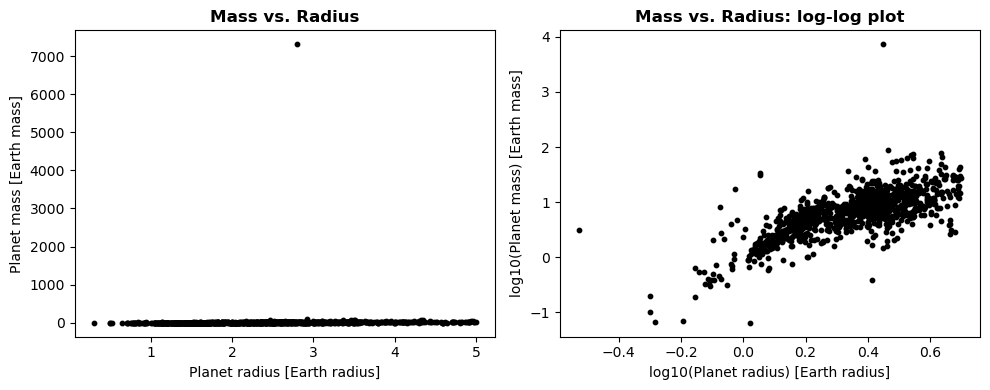

In [7]:
planet_mass = Sample_B['pl_masse']
planet_radius = Sample_B['pl_rade']

planet_mass_log = np.log10(planet_mass)
planet_radius_log = np.log10(planet_radius)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1
axes[0].scatter(planet_radius, planet_mass, s=10, color='black')
axes[0].set_xlabel('Planet radius [Earth radius]')
axes[0].set_ylabel('Planet mass [Earth mass]')
axes[0].set_title('Mass vs. Radius', fontsize=12, fontweight='bold')

# Plot 2: log mass
axes[1].scatter(planet_radius_log, planet_mass_log, s=10, color='black')
axes[1].set_xlabel('log10(Planet radius) [Earth radius]')
axes[1].set_ylabel('log10(Planet mass) [Earth mass]')
axes[1].set_title('Mass vs. Radius: log-log plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 2 - Linear regression

### 1D linear regression model (using scipy's stats.linregress)

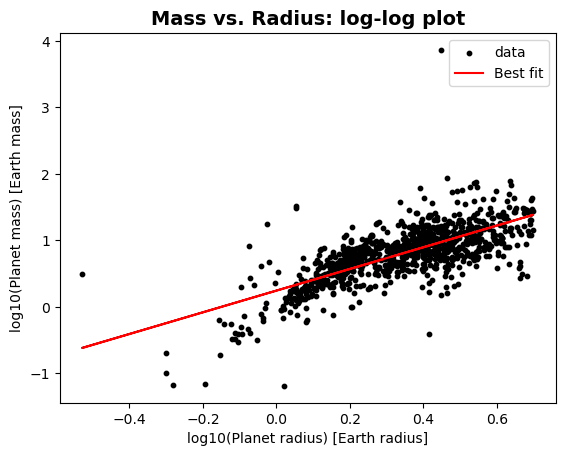

In [8]:
slope, intercept, r, p, std_err = stats.linregress(planet_radius_log, planet_mass_log)

def lin_model(R, a, b):
    return a * R + b

planet_mass_fit =  lin_model(planet_radius_log, slope, intercept)

plt.scatter(planet_radius_log, planet_mass_log, s = 10, color='black', label='data')
plt.plot(planet_radius_log, planet_mass_fit, color='red', label='Best fit')
plt.xlabel('log10(Planet radius) [Earth radius]')
plt.ylabel('log10(Planet mass) [Earth mass]')
plt.title('Mass vs. Radius: log-log plot', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

### 1D linear regression model (using scipy's curve_fit to take erros into account)

**Errors:**

Each data point has its own uncertainty, so not all point should be treated in the same way: use weighted likelihood:

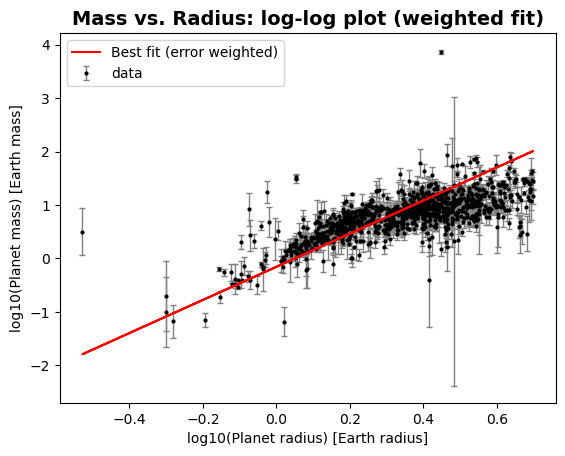

In [9]:
mass_error = Sample_B['mass_error_mean']
mass_error_log = mass_error / (planet_mass * np.log(10))  # correctly transfer errors into log space

params, cov = curve_fit(lin_model, planet_radius_log, planet_mass_log, sigma=mass_error, absolute_sigma=True)
slope_weighted, intercept_weighted = params

planet_mass_fit_weighted = lin_model(planet_radius_log, slope_weighted, intercept_weighted)

plt.errorbar(planet_radius_log, planet_mass_log, yerr=mass_error_log, fmt='o', markersize= 2, elinewidth=1, color='black', ecolor='gray', capsize=2, zorder=1, label='data')
plt.plot(planet_radius_log, planet_mass_fit_weighted, color='red', label='Best fit (error weighted)', zorder=3)
plt.xlabel('log10(Planet radius) [Earth radius]')
plt.ylabel('log10(Planet mass) [Earth mass]')
plt.title('Mass vs. Radius: log-log plot (weighted fit)', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

compare slopes and intercepts:

In [10]:
print('Slope, intercept withouth errors: ', round(slope, 3), round(intercept, 3))
print('Weighted slope, intercept: ', round(slope_weighted, 3), round(intercept_weighted, 3))

Slope, intercept withouth errors:  1.63 0.246
Weighted slope, intercept:  3.1 -0.158


**Can the linear models reproduce the masses of the solar system planets?**

In [11]:
# Radii of the planets (taken from literature) in Earth units

Mercury_radius = 0.382
Venus_radius = 0.949
Earth_radius = 1
Mars_radius = 0.532
Jupiter_radius = 11.209
Saturn_radius = 9.449
Uranus_radius = 4.007
Neptune_radius = 3.883

planet_names = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']

solar_system_planets_radii = np.array([Mercury_radius, Venus_radius, Earth_radius, Mars_radius, Jupiter_radius, Saturn_radius, Uranus_radius, Neptune_radius])
solar_system_planets_radii_log = np.log10(solar_system_planets_radii)


In [12]:
# Prediction of solar system planets mass (linear model without taking errors into consideration):

mass_planets_solar_system_log_fit = lin_model(solar_system_planets_radii_log, slope, intercept)
mass_planets_solar_system_fit = 10**mass_planets_solar_system_log_fit

df_planets = pd.DataFrame({
    'Planet': planet_names,
    'Predicted mass [Earth mass]': mass_planets_solar_system_fit
})

print(df_planets)

    Planet  Predicted mass [Earth mass]
0  Mercury                     0.367023
1    Venus                     1.617971
2    Earth                     1.762108
3     Mars                     0.629798
4  Jupiter                    90.590834
5   Saturn                    68.572656
6   Uranus                    16.934642
7  Neptune                    16.088665


In [13]:
# Prediction of solar system planets mass (linear model with errors taken into account):

mass_planets_solar_system_log_fit_weighted = lin_model(solar_system_planets_radii_log, slope_weighted, intercept_weighted)
mass_planets_solar_system_fit_weighted = 10**mass_planets_solar_system_log_fit_weighted

df_planets_weighted = pd.DataFrame({
    'Planet': planet_names,
    'Predicted mass [Earth mass] with error weights': mass_planets_solar_system_fit_weighted
})

print(df_planets_weighted)

    Planet  Predicted mass [Earth mass] with error weights
0  Mercury                                        0.035210
1    Venus                                        0.591470
2    Earth                                        0.695690
3     Mars                                        0.098320
4  Jupiter                                     1248.679288
5   Saturn                                      735.297415
6   Uranus                                       51.448503
7  Neptune                                       46.670964


### 1D Polynomial fit (using numpy polyfit):

In [14]:
pl_radius_A_log = np.log10(Sample_A['pl_rade'])
pl_mass_A_log = np.log10(Sample_A['pl_masse'])

mass_error_A = Sample_A['mass_error_mean']
mass_error_A_log = mass_error_A / (Sample_A['pl_masse'] * np.log(10))  # transfer error to log space:


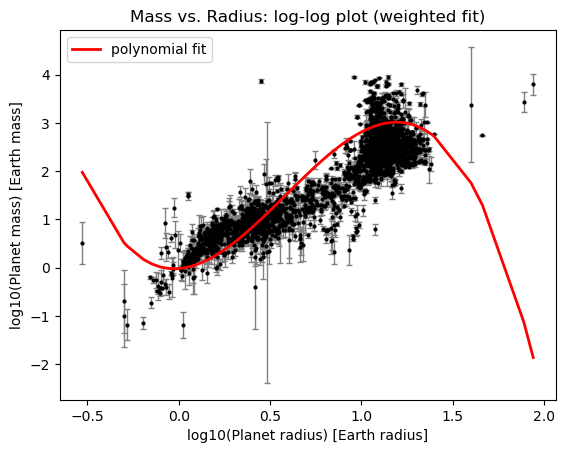

In [15]:
# 1D polynomial model (using np.polyfit())

weights_A = 1 / (mass_error_A_log**2)  # weights
d = 3  # polynomial degree

# polynomail fit
coeffs = np.polyfit(pl_radius_A_log, pl_mass_A_log, deg=d, w=weights_A)
mass_fit_A_log = np.polyval(coeffs, pl_radius_A_log)

# sorting to get a smooth line
sort = np.argsort(pl_radius_A_log)
radius_sorted = pl_radius_A_log[sort]
mass_fit_sorted = np.polyval(coeffs, radius_sorted)

plt.errorbar(pl_radius_A_log, pl_mass_A_log, yerr=mass_error_A_log, fmt='o', markersize= 2, elinewidth=1, color='black', ecolor='gray', capsize=2, zorder=1)
plt.plot(radius_sorted, mass_fit_sorted, color='red', linewidth=2, label='polynomial fit', zorder=3)
plt.xlabel('log10(Planet radius) [Earth radius]')
plt.ylabel('log10(Planet mass) [Earth mass]')
plt.title('Mass vs. Radius: log-log plot (weighted fit)')
plt.legend()
plt.show()


Comparison:

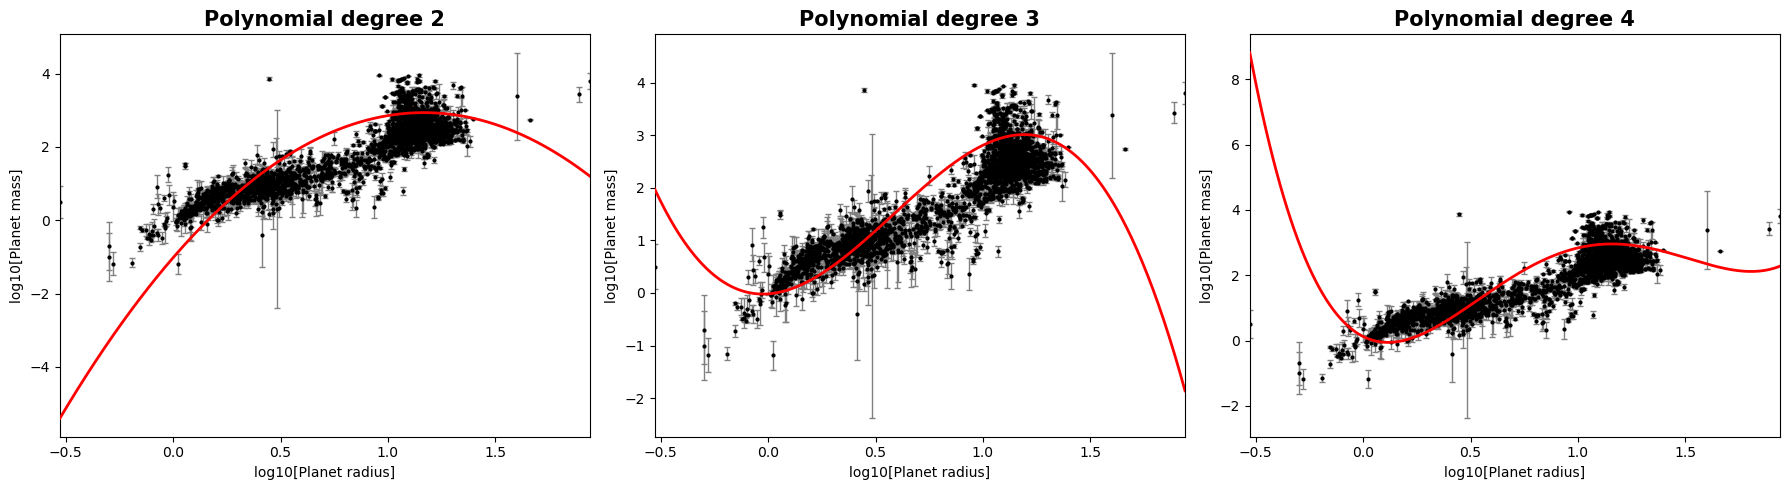

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

degrees = [2, 3, 4]

# for smooth grid:
x_fit = np.linspace(pl_radius_A_log.min(), pl_radius_A_log.max(), 300)

for i, d in enumerate(degrees):

    # Polynomial fit
    coeffs_poly = np.polyfit(pl_radius_A_log, pl_mass_A_log, deg=d, w=weights_A)
    y_fit = np.polyval(coeffs_poly, x_fit)

    # Plots
    axs[i].errorbar(pl_radius_A_log, pl_mass_A_log, yerr=mass_error_A_log, fmt='o', markersize=2, elinewidth=1, color='black', ecolor='gray', capsize=2, zorder=1)
    axs[i].plot(x_fit, y_fit, color='red', linewidth=2, zorder=3)
    axs[i].set_xlabel('log10[Planet radius]')
    axs[i].set_ylabel('log10[Planet mass]')
    axs[i].set_title(f'Polynomial degree {d}', fontsize=15, fontweight='bold')

    # keep same view for fair comparison
    axs[i].set_xlim(pl_radius_A_log.min(), pl_radius_A_log.max(),)

plt.tight_layout()
plt.show()

**Can the polynomial model reproduce the masses of the solar system planets?**

In [17]:
# Prediction of solar system planets mass (polynomial model):

solar_system_planets_mass_A_log_fit = np.polyval(coeffs, solar_system_planets_radii_log)
solar_system_planets_mass_A_fit = 10**solar_system_planets_mass_A_log_fit

df_solar_system_planets_A = pd.DataFrame({
    'Planet': planet_names,
    'Predicted mass [Earth mass] with error weights': solar_system_planets_mass_A_fit
})

print(df_solar_system_planets_A)

    Planet  Predicted mass [Earth mass] with error weights
0  Mercury                                       13.744716
1    Venus                                        0.951595
2    Earth                                        0.959479
3     Mars                                        2.600582
4  Jupiter                                      790.890725
5   Saturn                                      574.098552
6   Uranus                                       36.934319
7  Neptune                                       32.836165


### 2D linear regression (using sklearn's LinearRegression)

In [18]:
# use/change variable names to X and y for better readability

X = np.column_stack((
    np.log10(Sample_B['pl_rade']),
    np.log10(Sample_B['st_mass'])   # stellar mass column
))

y = planet_mass_log

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

In [19]:
print("1D R2:", r2_score(planet_mass_log, planet_mass_fit_weighted))
print("2D R2:", r2_score(y, y_pred))

1D R2: 0.04354855218771825
2D R2: 0.5522294651346926


In [25]:
# stellar mass (same for all planets, in Earth masses)
solar_system_stellar_mass_log = np.log10(np.array([1] * len(solar_system_planets_radii)))

X_solar_system = np.column_stack((
    solar_system_planets_radii_log,
    solar_system_stellar_mass_log
))

model = LinearRegression()
model.fit(X, y)

solar_system_planets_mass_log_fit = model.predict(X_solar_system)
solar_system_planets_mass_fit = 10**solar_system_planets_mass_log_fit


df_planets_A_2D = pd.DataFrame({
    'Planet': planet_names,
    'Predicted mass [Earth mass] (2D model)': solar_system_planets_mass_fit
})

print(df_planets_A_2D)

    Planet  Predicted mass [Earth mass] (2D model)
0  Mercury                                0.578188
1    Venus                                2.140301
2    Earth                                2.307661
3     Mars                                0.931024
4  Jupiter                               74.597818
5   Saturn                               58.349111
6   Uranus                               16.989684
7  Neptune                               16.238660
